# Method Comparison (Single Workload)

Bar charts comparing all methods at their best budget.
Select one workload to analyze.

In [334]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({
    'font.size': 11,
    'figure.dpi': 100,
})

In [335]:
# ========== SELECT WORKLOAD AND COST MODE HERE ==========
BASE = "../results/qwen3_8b"

WORKLOAD_OPTIONS = {
    "W1": ("BFCLv4 memory_kv (req0-12)",     f"{BASE}/bfcl_v4_req0-12/tree_oracle_sim.json"),
    "W2": ("BFCLv3 multi_turn (req0-12)",    f"{BASE}/bfcl_v3_req0-12/tree_oracle_sim.json"),
    "W3": ("SpecBench (req0-3)",             f"{BASE}/specbench_req0-3/tree_oracle_sim.json"),
    "W4": ("BFCLv4 web_search (req576-579)", f"{BASE}/bfcl_v4_req576-579/tree_oracle_sim.json"),
    "W5": ("SWEBench (req0-3)",              f"{BASE}/swebench_req0-3/tree_oracle_sim.json"),
}

# >>> CHANGE THESE <<<
SELECTED = "W5"
USE_REAL_COST = True    # True = measured latencies, False = ratio-based
RATIO = 0.1             # only used when USE_REAL_COST = False
ORACLE_BUDGET = 300     # fixed budget for oracle methods

workload_name, workload_path = WORKLOAD_OPTIONS[SELECTED]
with open(workload_path) as f:
    data = json.load(f)

latency_path = workload_path.replace('tree_oracle_sim.json', 'latency_config.json')
try:
    with open(latency_path) as f:
        lc = json.load(f)
    vanilla_ms = lc['vanilla_step_ms']
except:
    vanilla_ms = 21.07

# Cost-mode label for chart titles
COST_LABEL = "real cost" if USE_REAL_COST else f"ratio={RATIO}"

print(f"Workload: {SELECTED} — {workload_name}")
if USE_REAL_COST:
    print("Draft cost: REAL (measured latencies)")
else:
    print(f"Draft cost ratio: {RATIO} (step = verify × {1+RATIO:.2f})")
print(f"Oracle budget: B={ORACLE_BUDGET}")

Workload: W5 — SWEBench (req0-3)
Draft cost: REAL (measured latencies)
Oracle budget: B=300


In [336]:
# Parse budget table
df = pd.DataFrame(data["latency"]["budget_sweep"])

# Speedup key: real-cost or ratio-based
spd_suffix = "_speedup_real" if USE_REAL_COST else f"_speedup_r{RATIO}"

# Oracle methods (extension-type): pick at ORACLE_BUDGET
ORACLE_METHODS = {'extension', 'extension_all', 'extension_dmsfx'}

# Always-at-max-budget: suffix (budget-independent) and Choose-One (full tree, no truncation)
MAX_BUDGET_METHODS = {'suffix', 'c1', 'c1_e3sfx', 'c1_e3dm'}

# Hide legacy union_trie column if new e3sfx variant is present
HIDE_METHODS = set()
if 'union_trie_e3sfx' + spd_suffix in df.columns:
    HIDE_METHODS.add('union_trie')

max_budget = int(df['budget'].max())
methods = []
for col in df.columns:
    if col.endswith(spd_suffix):
        name = col.replace(spd_suffix, '')
        if name.endswith('_always'):
            continue
        if name in HIDE_METHODS:
            continue
        if name in MAX_BUDGET_METHODS:
            row = df[df['budget'] == max_budget]
            idx = row.index[0]
        elif name in ORACLE_METHODS:
            row = df[df['budget'] == ORACLE_BUDGET]
            if len(row) == 0:
                row = df.iloc[[-1]]
            idx = row.index[0]
        else:
            idx = df[col].idxmax()
        best_b = int(df['budget'].iloc[idx])
        mc = f'{name}_mat'
        methods.append({
            'method': name,
            'best_budget': best_b,
            'speedup': df[col].iloc[idx],
            'mat': df[mc].iloc[idx] if mc in df.columns else 0,
        })

mdf = pd.DataFrame(methods)

# Keep only best threshold per hybrid group
for prefix in ['hybrid_e3_t', 'hybrid_dm_t']:
    mask = mdf['method'].str.startswith(prefix)
    group = mdf[mask]
    if len(group) > 1:
        best_idx = group['speedup'].idxmax()
        drop_idx = group.index[group.index != best_idx]
        mdf = mdf.drop(drop_idx)
mdf = mdf.reset_index(drop=True)

# Labels
def make_label(name):
    labels = {
        'eagle3': 'EAGLE3',
        'suffix': 'Suffix',
        'draft_model': 'Draft Model',
        'union_trie': 'Union Trie',
        'union_trie_e3sfx': 'Union Trie (E3+Sfx)',
        'union_trie_all': 'Union Trie (All)',
        'extension': 'Extension (E3+Sfx)',
        'extension_dmsfx': 'Extension (DM+Sfx)',
        'extension_all': 'Extension (All)',
        'c1_e3sfx': 'Choose-One (E3+Sfx)',
        'c1_e3dm': 'Choose-One (E3+DM)',
        'c1': 'Choose-One (All)',
    }
    if name in labels:
        return labels[name]
    if name.startswith('hybrid_e3'):
        t = name.split('_t')[1]
        return f'Hybrid(Sfx->E3) t={t}'
    if name.startswith('hybrid_dm'):
        t = name.split('_t')[1]
        return f'Hybrid(Sfx->DM) t={t}'
    return name

# Explicit display order — Choose-One → Union Trie → Extension
ORDER = [
    'eagle3', 'suffix', 'draft_model',
    'hybrid_e3', 'hybrid_dm',
    'c1_e3sfx', 'c1_e3dm', 'c1',
    'union_trie_e3sfx', 'union_trie_all',
    'extension', 'extension_dmsfx',
]

def get_order(name):
    if name.startswith('hybrid_e3'):
        return ORDER.index('hybrid_e3')
    if name.startswith('hybrid_dm'):
        return ORDER.index('hybrid_dm')
    # Legacy 'union_trie' maps to e3sfx position
    if name == 'union_trie':
        return ORDER.index('union_trie_e3sfx')
    return ORDER.index(name) if name in ORDER else len(ORDER)

def get_color(name):
    if name == 'eagle3': return '#2ca02c'
    if name == 'suffix': return '#ff7f0e'
    if name == 'draft_model': return '#8c564b'
    if name in ('union_trie', 'union_trie_e3sfx'): return '#17becf'
    if name == 'union_trie_all': return '#0099a8'
    if 'hybrid_e3' in name: return '#9467bd'
    if 'hybrid_dm' in name: return '#e377c2'
    if name == 'extension': return '#d62728'
    if name == 'extension_dmsfx': return '#fc8d8d'
    if name == 'extension_all': return '#a51717'
    if name == 'c1_e3sfx': return '#6baed6'
    if name == 'c1_e3dm': return '#4a9fdb'
    if name == 'c1': return '#1f77b4'
    return '#7f7f7f'

mdf['label'] = mdf['method'].map(make_label)
mdf['color'] = mdf['method'].map(get_color)
mdf['order'] = mdf['method'].map(get_order)
mdf = mdf.sort_values('order').reset_index(drop=True)

print(f"Methods: {len(mdf)}, cost={COST_LABEL}, Oracle B={ORACLE_BUDGET}")
print(mdf[['label', 'best_budget', 'speedup', 'mat']].to_string(index=False))

Methods: 11, cost=real cost, Oracle B=300
                label  best_budget   speedup       mat
               EAGLE3          512  4.209538  3.209538
               Suffix          512  3.596296  2.596296
          Draft Model            1  0.891099  0.658689
Hybrid(Sfx->E3) t=5.0          512  8.468023  7.468023
Hybrid(Sfx->DM) t=1.0            1  3.007910  3.185345
  Choose-One (E3+Sfx)          512  9.396774  8.396774
     Choose-One (All)          512  0.027153  9.670330
  Union Trie (E3+Sfx)          512  9.396774  8.396774
     Union Trie (All)            1  0.895418  0.666285
   Extension (E3+Sfx)          512 16.183333 15.183333
   Extension (DM+Sfx)          512 11.160920 10.160920


## 1. Speedup Comparison

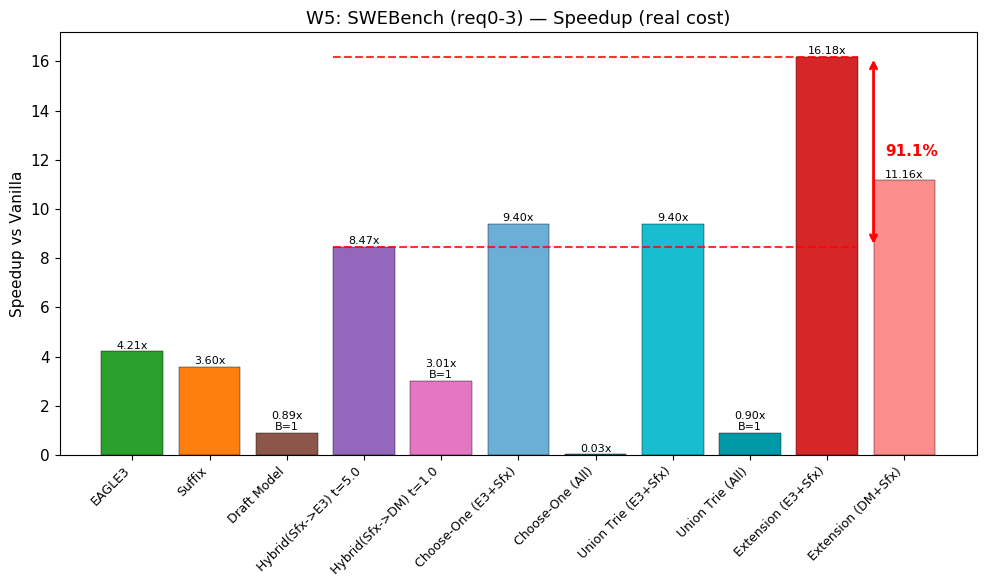

In [337]:
fig, ax = plt.subplots(figsize=(max(10, len(mdf) * 0.8), 6))

x = np.arange(len(mdf))
bars = ax.bar(x, mdf['speedup'].values, color=mdf['color'].values,
              edgecolor='black', linewidth=0.3)

_max_b = int(df['budget'].max())
for i, (spd, b) in enumerate(zip(mdf['speedup'].values, mdf['best_budget'].values)):
    if int(b) == _max_b:
        txt = f'{spd:.2f}x'
    else:
        txt = f'{spd:.2f}x\nB={b}'
    ax.text(i, spd + 0.03, txt, ha='center', va='bottom', fontsize=8)

# Gap: pick pair where HYBRID speedup is highest
methods_list = list(mdf['method'].values)
speedups_list = list(mdf['speedup'].values)

def _find_row(predicate):
    for i, m in enumerate(methods_list):
        if predicate(m):
            return i
    return None

pairs = [
    (lambda m: m.startswith('hybrid_e3_t') and not m.endswith('_always'),
     lambda m: m == 'extension'),
    (lambda m: m.startswith('hybrid_dm_t') and not m.endswith('_always'),
     lambda m: m == 'extension_dmsfx'),
]

best = None
for hyb_pred, ext_pred in pairs:
    h_pos = _find_row(hyb_pred)
    e_pos = _find_row(ext_pred)
    if h_pos is None or e_pos is None:
        continue
    h_spd = speedups_list[h_pos]
    e_spd = speedups_list[e_pos]
    # select pair by best hybrid speedup
    if best is None or h_spd > best[3]:
        best = (h_pos, e_pos, e_spd, h_spd)

if best is not None:
    h_pos, e_pos, e_spd, h_spd = best
    pct = abs((h_spd - e_spd) / h_spd * 100)

    x_lo, x_hi = sorted([h_pos, e_pos])
    ax.hlines(h_spd, x_lo - 0.4, x_hi + 0.4, colors='red',
              linestyles='--', alpha=0.8, linewidth=1.5)
    ax.hlines(e_spd, x_lo - 0.4, x_hi + 0.4, colors='red',
              linestyles='--', alpha=0.8, linewidth=1.5)

    arrow_x = x_hi + 0.6
    ax.annotate('', xy=(arrow_x, e_spd), xytext=(arrow_x, h_spd),
                arrowprops=dict(arrowstyle='<->', color='red', lw=2))
    ax.text(arrow_x + 0.15, (h_spd + e_spd) / 2, f'{pct:.1f}%',
            ha='left', va='center', color='red', fontsize=11, fontweight='bold')
    ax.set_ylim(top=max(speedups_list) + 1.0)

ax.set_xticks(x)
ax.set_xticklabels(mdf['label'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Speedup vs Vanilla')
ax.set_title(f'{SELECTED}: {workload_name} — Speedup ({COST_LABEL})', fontsize=13)
plt.tight_layout()
plt.show()

## 2. MAT (Mean Accepted Tokens) Comparison

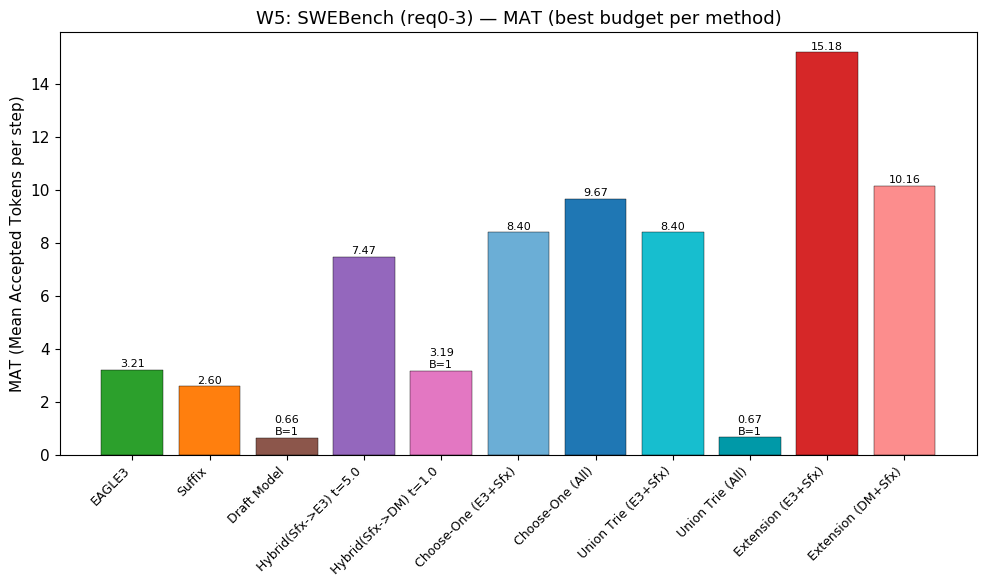

In [338]:
mdf_mat = mdf[mdf['mat'] > 0].copy()

if len(mdf_mat) > 0:
    fig, ax = plt.subplots(figsize=(max(10, len(mdf_mat) * 0.8), 6))
    
    x = np.arange(len(mdf_mat))
    bars = ax.bar(x, mdf_mat['mat'], color=mdf_mat['color'].values, edgecolor='black', linewidth=0.3)
    
    _max_b = int(df['budget'].max())
    for i, (mat, b) in enumerate(zip(mdf_mat['mat'], mdf_mat['best_budget'])):
        if int(b) == _max_b:
            txt = f'{mat:.2f}'
        else:
            txt = f'{mat:.2f}\nB={b}'
        ax.text(i, mat + 0.02, txt, ha='center', va='bottom', fontsize=8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(mdf_mat['label'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('MAT (Mean Accepted Tokens per step)')
    ax.set_title(f'{SELECTED}: {workload_name} — MAT (best budget per method)', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No MAT data available')

## 3. Speedup vs MAT Scatter

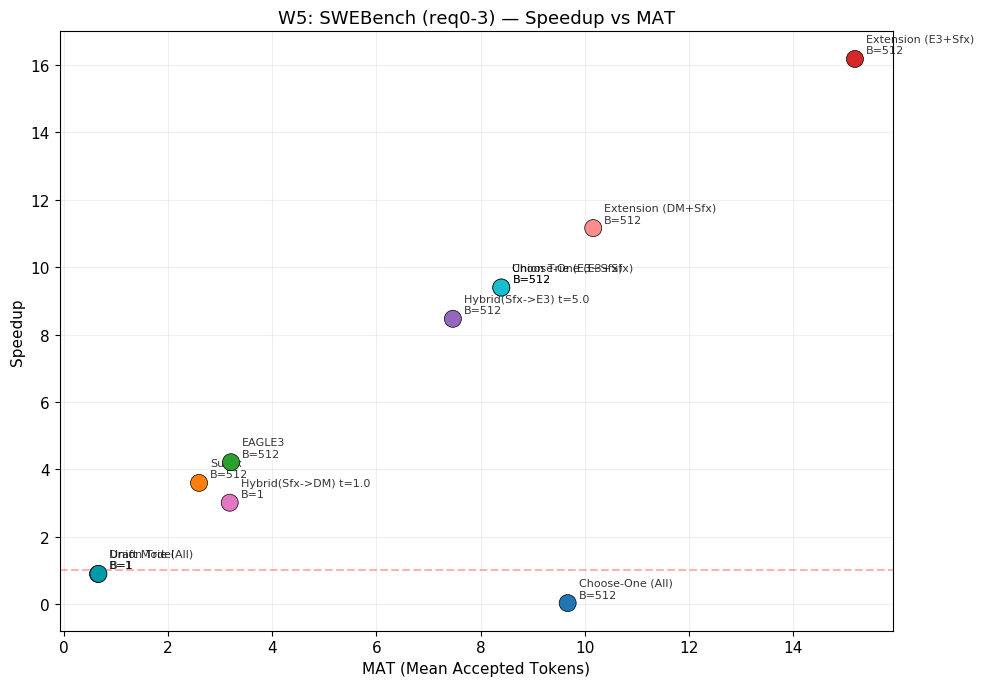

In [339]:
mdf_both = mdf[mdf['mat'] > 0].copy()

if len(mdf_both) > 0:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    ax.scatter(mdf_both['mat'], mdf_both['speedup'], 
               c=mdf_both['color'], s=150, edgecolors='black', linewidth=0.5, zorder=5)
    
    for _, r in mdf_both.iterrows():
        ax.annotate(f"{r['label']}\nB={r['best_budget']}",
                    (r['mat'], r['speedup']),
                    textcoords='offset points', xytext=(8, 4),
                    fontsize=8, alpha=0.8)
    
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
    ax.set_xlabel('MAT (Mean Accepted Tokens)')
    ax.set_ylabel('Speedup')
    ax.set_title(f'{SELECTED}: {workload_name} — Speedup vs MAT', fontsize=13)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print('No data')

## 4. Speedup across Ratios (Selected Budget)

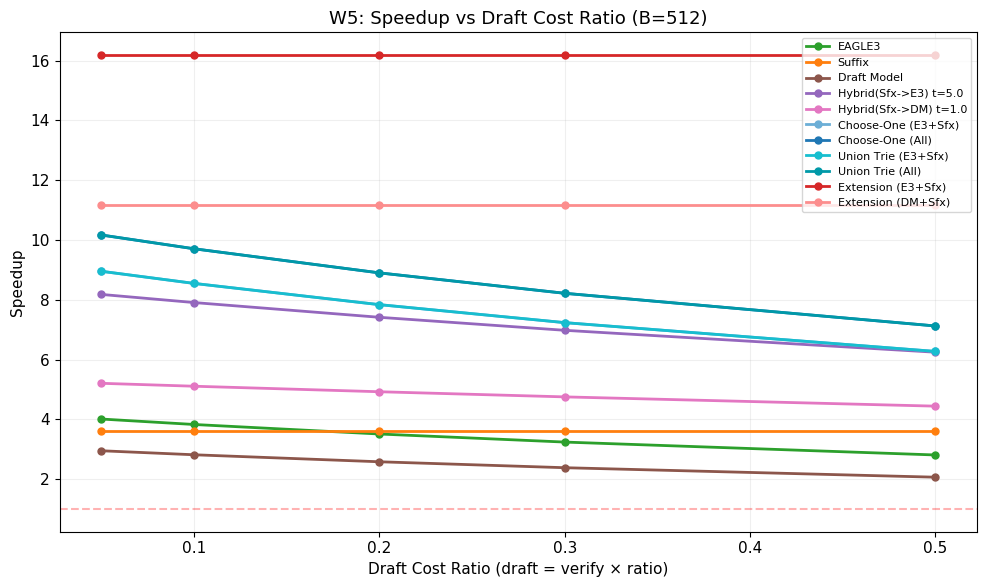

In [340]:
# Show how speedup changes with draft cost ratio for top methods at ORACLE_BUDGET
ratios = [0.05, 0.1, 0.2, 0.3, 0.5]
b_row = df[df['budget'] == ORACLE_BUDGET]
if len(b_row) == 0:
    b_row = df.iloc[[-1]]
b_row = b_row.iloc[0]

fig, ax = plt.subplots(figsize=(10, 6))

for _, r in mdf.iterrows():
    name = r['method']
    spds = [b_row.get(f'{name}_speedup_r{ratio}', 0) for ratio in ratios]
    if any(s > 0 for s in spds):
        ax.plot(ratios, spds, 'o-', label=r['label'], color=r['color'], linewidth=2, markersize=5)

ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
ax.set_xlabel('Draft Cost Ratio (draft = verify × ratio)')
ax.set_ylabel('Speedup')
ax.set_title(f'{SELECTED}: Speedup vs Draft Cost Ratio (B={int(b_row["budget"])})', fontsize=13)
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Summary Table

In [341]:
print(f"{'='*75}")
print(f"{SELECTED}: {workload_name} ({COST_LABEL})")
print(f"{'='*75}")
print()
print(f"{'Method':<30} {'Budget':>6} {'Speedup':>8} {'MAT':>6}")
print('-' * 55)
for _, r in mdf.iterrows():
    mat_str = f"{r['mat']:.2f}" if r['mat'] > 0 else '-'
    print(f"{r['label']:<30} B={r['best_budget']:>3}  {r['speedup']:>7.2f}x {mat_str:>6}")
print(f"{'='*75}")

W5: SWEBench (req0-3) (real cost)

Method                         Budget  Speedup    MAT
-------------------------------------------------------
EAGLE3                         B=512     4.21x   3.21
Suffix                         B=512     3.60x   2.60
Draft Model                    B=  1     0.89x   0.66
Hybrid(Sfx->E3) t=5.0          B=512     8.47x   7.47
Hybrid(Sfx->DM) t=1.0          B=  1     3.01x   3.19
Choose-One (E3+Sfx)            B=512     9.40x   8.40
Choose-One (All)               B=512     0.03x   9.67
Union Trie (E3+Sfx)            B=512     9.40x   8.40
Union Trie (All)               B=  1     0.90x   0.67
Extension (E3+Sfx)             B=512    16.18x  15.18
Extension (DM+Sfx)             B=512    11.16x  10.16


## 6. Budget Sensitivity (Selected Methods)

/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


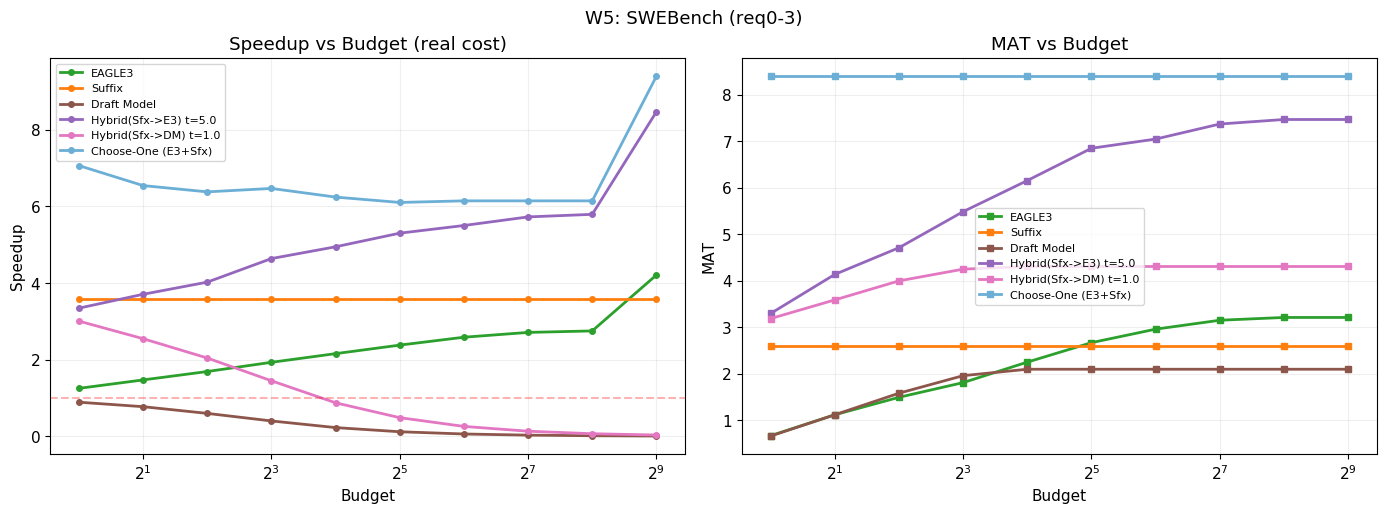

In [342]:
# Budget sensitivity for top methods
top_methods = mdf.head(6)['method'].tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name in top_methods:
    col_spd = f'{name}{spd_suffix}'
    col_mat = f'{name}_mat'
    label = make_label(name)
    color = get_color(name)

    if col_spd in df.columns:
        ax1.plot(df['budget'], df[col_spd], 'o-', label=label, color=color, linewidth=2, markersize=4)
    if col_mat in df.columns:
        ax2.plot(df['budget'], df[col_mat], 's-', label=label, color=color, linewidth=2, markersize=4)

ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
ax1.set_xlabel('Budget')
ax1.set_ylabel('Speedup')
ax1.set_title(f'Speedup vs Budget ({COST_LABEL})')
ax1.set_xscale('log', basex=2)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.2)

ax2.set_xlabel('Budget')
ax2.set_ylabel('MAT')
ax2.set_title('MAT vs Budget')
ax2.set_xscale('log', basex=2)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.2)

plt.suptitle(f'{SELECTED}: {workload_name}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Add1: Exclude Extension & Union — Speedup (Gap: Hybrid → Choose-One)

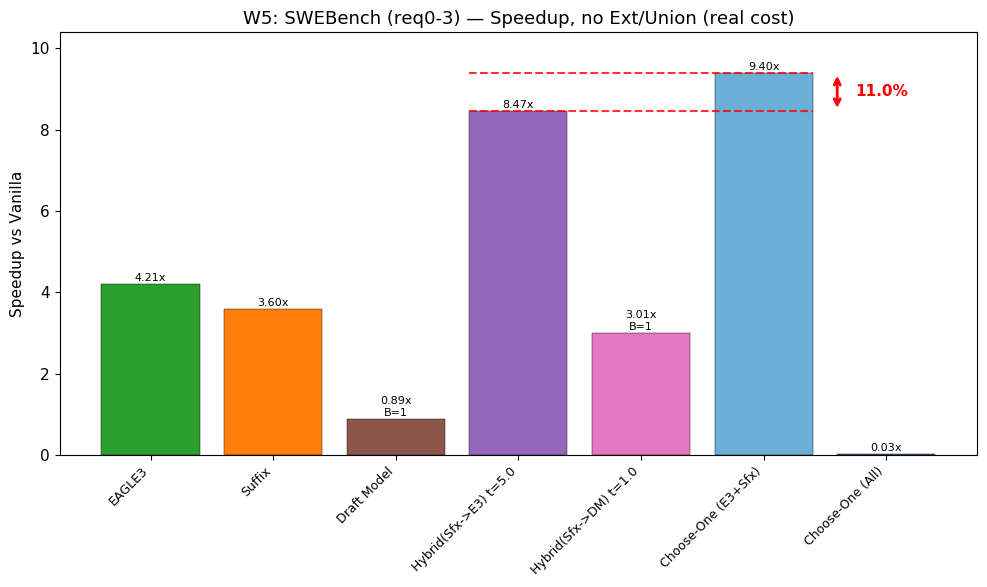

In [343]:
# Filter: exclude Extension and Union Trie
EXCLUDE_1 = {'extension', 'extension_dmsfx', 'extension_all',
             'union_trie', 'union_trie_e3sfx', 'union_trie_all'}
mdf1 = mdf[~mdf['method'].isin(EXCLUDE_1)].reset_index(drop=True)

methods1 = list(mdf1['method'].values)
speedups1 = list(mdf1['speedup'].values)

def _find1(pred):
    for i, m in enumerate(methods1):
        if pred(m):
            return i
    return None

pairs1 = [
    (lambda m: m.startswith('hybrid_e3_t') and not m.endswith('_always'),
     lambda m: m == 'c1_e3sfx'),
    (lambda m: m.startswith('hybrid_dm_t') and not m.endswith('_always'),
     lambda m: m == 'c1_e3dm'),
    (lambda m: m.startswith('hybrid_e3_t') and not m.endswith('_always'),
     lambda m: m == 'c1'),
    (lambda m: m.startswith('hybrid_dm_t') and not m.endswith('_always'),
     lambda m: m == 'c1'),
]
best1 = None
for hp, tp in pairs1:
    hi = _find1(hp); ti = _find1(tp)
    if hi is None or ti is None:
        continue
    t_spd = speedups1[ti]; h_spd = speedups1[hi]
    # select pair by best hybrid speedup
    if best1 is None or h_spd > best1[3]:
        best1 = (hi, ti, t_spd, h_spd)

fig, ax = plt.subplots(figsize=(max(10, len(mdf1) * 0.9), 6))

x = np.arange(len(mdf1))
ax.bar(x, mdf1['speedup'].values, color=mdf1['color'].values,
       edgecolor='black', linewidth=0.3)
_max_b = int(df['budget'].max())
for i, (spd, b) in enumerate(zip(mdf1['speedup'].values, mdf1['best_budget'].values)):
    txt = f'{spd:.2f}x' if int(b) == _max_b else f'{spd:.2f}x\nB={b}'
    ax.text(i, spd + 0.03, txt, ha='center', va='bottom', fontsize=8)

if best1 is not None:
    hi, ti, t_spd, h_spd = best1
    pct = abs((h_spd - t_spd) / h_spd * 100)
    x_lo, x_hi = sorted([hi, ti])
    ax.hlines(h_spd, x_lo - 0.4, x_hi + 0.4, colors='red',
              linestyles='--', alpha=0.8, linewidth=1.5)
    ax.hlines(t_spd, x_lo - 0.4, x_hi + 0.4, colors='red',
              linestyles='--', alpha=0.8, linewidth=1.5)
    arrow_x = x_hi + 0.6
    ax.annotate('', xy=(arrow_x, t_spd), xytext=(arrow_x, h_spd),
                arrowprops=dict(arrowstyle='<->', color='red', lw=2))
    ax.text(arrow_x + 0.15, (h_spd + t_spd) / 2, f'{pct:.1f}%',
            ha='left', va='center', color='red', fontsize=11, fontweight='bold')
    ax.set_ylim(top=max(speedups1) + 1.0)

ax.set_xticks(x)
ax.set_xticklabels(mdf1['label'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Speedup vs Vanilla')
ax.set_title(f'{SELECTED}: {workload_name} — Speedup, no Ext/Union ({COST_LABEL})',
             fontsize=13)
plt.tight_layout()
plt.show()

## 8. Add1: Exclude Extension & Union — MAT

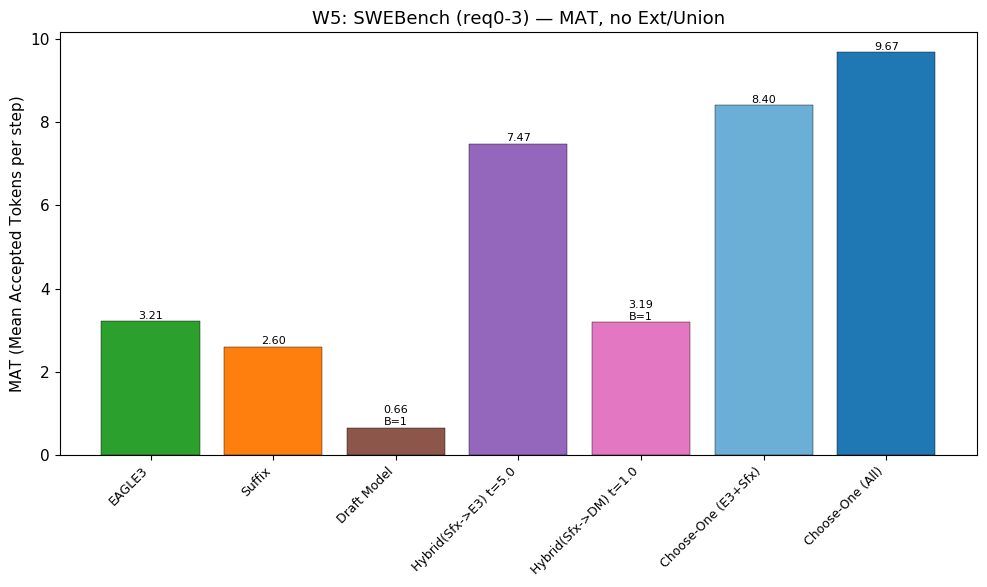

In [344]:
mdf1_mat = mdf1[mdf1['mat'] > 0].copy()

if len(mdf1_mat) > 0:
    fig, ax = plt.subplots(figsize=(max(10, len(mdf1_mat) * 0.9), 6))
    x = np.arange(len(mdf1_mat))
    ax.bar(x, mdf1_mat['mat'], color=mdf1_mat['color'].values,
           edgecolor='black', linewidth=0.3)
    _max_b = int(df['budget'].max())
    for i, (mat, b) in enumerate(zip(mdf1_mat['mat'], mdf1_mat['best_budget'])):
        txt = f'{mat:.2f}' if int(b) == _max_b else f'{mat:.2f}\nB={b}'
        ax.text(i, mat + 0.02, txt, ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(mdf1_mat['label'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('MAT (Mean Accepted Tokens per step)')
    ax.set_title(f'{SELECTED}: {workload_name} — MAT, no Ext/Union', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No MAT data')

## 9. Add2: Exclude Extension — Speedup (Gap: Hybrid → Union Trie)

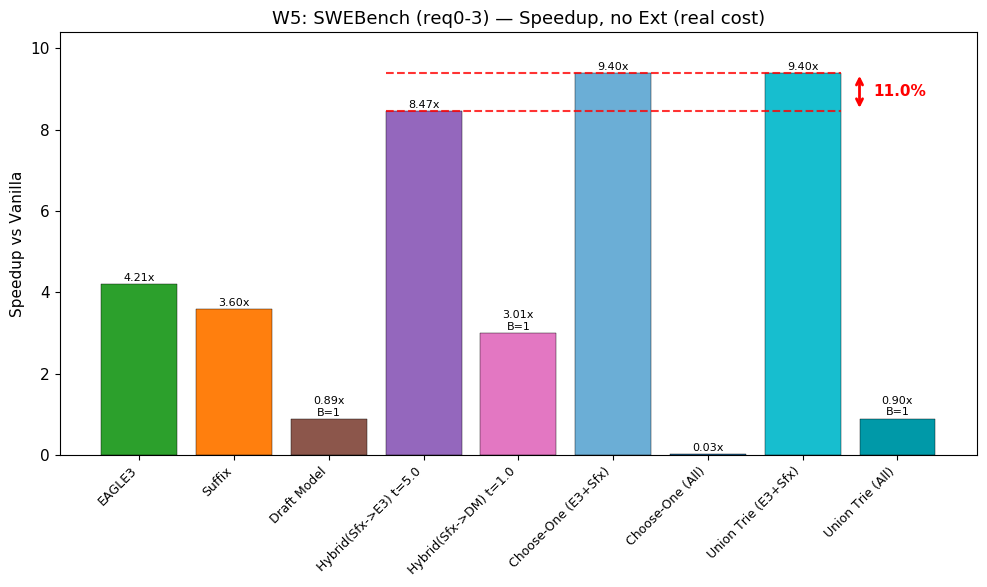

In [345]:
# Filter: exclude Extension only
EXCLUDE_2 = {'extension', 'extension_dmsfx', 'extension_all'}
mdf2 = mdf[~mdf['method'].isin(EXCLUDE_2)].reset_index(drop=True)

methods2 = list(mdf2['method'].values)
speedups2 = list(mdf2['speedup'].values)

def _find2(pred):
    for i, m in enumerate(methods2):
        if pred(m):
            return i
    return None

pairs2 = [
    (lambda m: m.startswith('hybrid_e3_t') and not m.endswith('_always'),
     lambda m: m == 'union_trie_e3sfx'),
    (lambda m: m.startswith('hybrid_dm_t') and not m.endswith('_always'),
     lambda m: m == 'union_trie_all'),
    (lambda m: m.startswith('hybrid_e3_t') and not m.endswith('_always'),
     lambda m: m == 'union_trie_all'),
]
best2 = None
for hp, tp in pairs2:
    hi = _find2(hp); ti = _find2(tp)
    if hi is None or ti is None:
        continue
    t_spd = speedups2[ti]; h_spd = speedups2[hi]
    # select pair by best hybrid speedup
    if best2 is None or h_spd > best2[3]:
        best2 = (hi, ti, t_spd, h_spd)

fig, ax = plt.subplots(figsize=(max(10, len(mdf2) * 0.9), 6))

x = np.arange(len(mdf2))
ax.bar(x, mdf2['speedup'].values, color=mdf2['color'].values,
       edgecolor='black', linewidth=0.3)
_max_b = int(df['budget'].max())
for i, (spd, b) in enumerate(zip(mdf2['speedup'].values, mdf2['best_budget'].values)):
    txt = f'{spd:.2f}x' if int(b) == _max_b else f'{spd:.2f}x\nB={b}'
    ax.text(i, spd + 0.03, txt, ha='center', va='bottom', fontsize=8)

if best2 is not None:
    hi, ti, t_spd, h_spd = best2
    pct = abs((h_spd - t_spd) / h_spd * 100)
    x_lo, x_hi = sorted([hi, ti])
    ax.hlines(h_spd, x_lo - 0.4, x_hi + 0.4, colors='red',
              linestyles='--', alpha=0.8, linewidth=1.5)
    ax.hlines(t_spd, x_lo - 0.4, x_hi + 0.4, colors='red',
              linestyles='--', alpha=0.8, linewidth=1.5)
    arrow_x = x_hi + 0.6
    ax.annotate('', xy=(arrow_x, t_spd), xytext=(arrow_x, h_spd),
                arrowprops=dict(arrowstyle='<->', color='red', lw=2))
    ax.text(arrow_x + 0.15, (h_spd + t_spd) / 2, f'{pct:.1f}%',
            ha='left', va='center', color='red', fontsize=11, fontweight='bold')
    ax.set_ylim(top=max(speedups2) + 1.0)

ax.set_xticks(x)
ax.set_xticklabels(mdf2['label'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Speedup vs Vanilla')
ax.set_title(f'{SELECTED}: {workload_name} — Speedup, no Ext ({COST_LABEL})',
             fontsize=13)
plt.tight_layout()
plt.show()

## 10. Add2: Exclude Extension — MAT

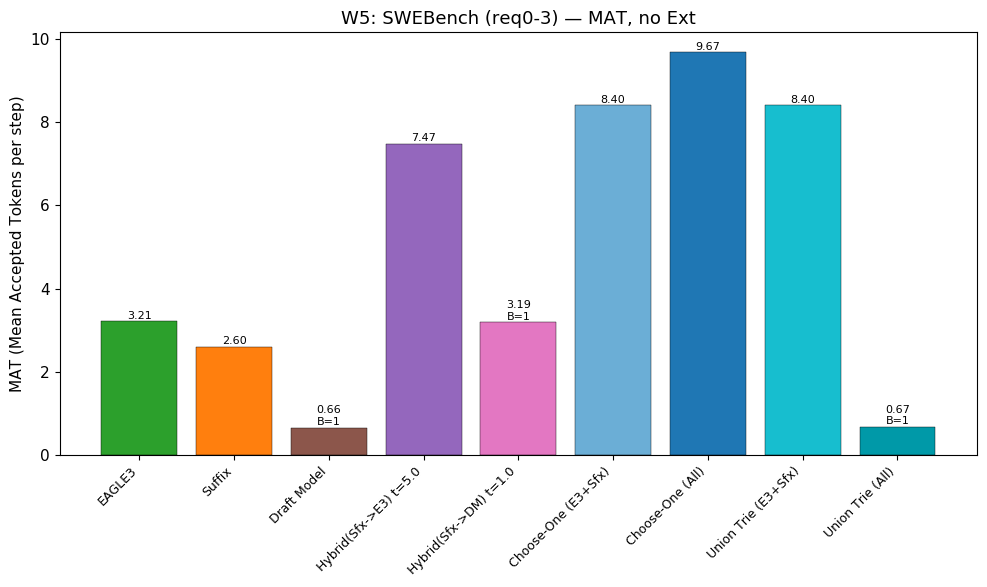

In [346]:
mdf2_mat = mdf2[mdf2['mat'] > 0].copy()

if len(mdf2_mat) > 0:
    fig, ax = plt.subplots(figsize=(max(10, len(mdf2_mat) * 0.9), 6))
    x = np.arange(len(mdf2_mat))
    ax.bar(x, mdf2_mat['mat'], color=mdf2_mat['color'].values,
           edgecolor='black', linewidth=0.3)
    _max_b = int(df['budget'].max())
    for i, (mat, b) in enumerate(zip(mdf2_mat['mat'], mdf2_mat['best_budget'])):
        txt = f'{mat:.2f}' if int(b) == _max_b else f'{mat:.2f}\nB={b}'
        ax.text(i, mat + 0.02, txt, ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(mdf2_mat['label'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('MAT (Mean Accepted Tokens per step)')
    ax.set_title(f'{SELECTED}: {workload_name} — MAT, no Ext', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No MAT data')